In [1]:
%load_ext autoreload
%autoreload 2
import os
os.chdir('../..')
from sqlcompletions.evaluator import run_plot_parameter, create_tests
from sqlcompletions.sqlparser import schema

k_to_test = {1: 1, 3:3, 5:5, 7:7,10:10 }
def tests(discretization_method):
    db = schema(db_stats=True,discretization_method=discretization_method)
    tests = []
    for k in k_to_test:
        add_tests = create_tests(algorithms= ["egreedy","thompson", "ucb", "pucb","popularRegion","all"], clause=3, top_k = k , db = db, th=500 )
        for test in add_tests: # add common
            test.update({
                'parameter_value': k
            })
        tests += add_tests
    return tests

CPU times: user 156 ms, sys: 38.9 ms, total: 195 ms
Wall time: 57.1 s


,Algorithm,1,3,5,7,10
0,Egreedy,0.13,0.15,0.17,0.18,0.19
1,UCB,0.12,0.18,0.20,0.21,0.23
2,pUCB,0.10,0.14,0.16,0.18,0.19
3,Thompson Sampling,0.11,0.16,0.18,0.19,0.21
4,Best Bin,0.29,0.29,0.29,0.29,0.29
5,Most popular,0.13,0.15,0.17,0.19,0.20


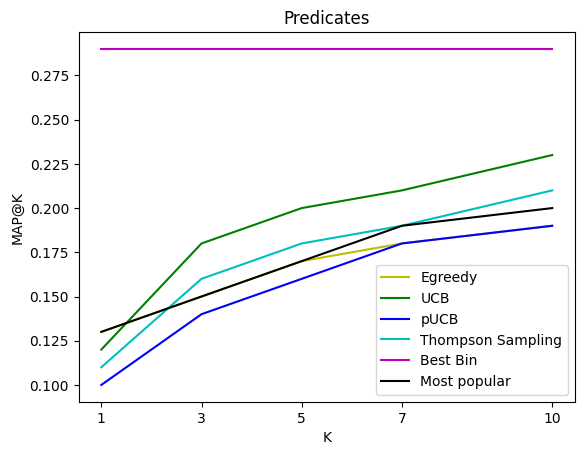

In [6]:
%%time
run_plot_parameter(tests("equal-width"), parameter_name = "K", param_map = k_to_test).results

CPU times: user 216 ms, sys: 42.7 ms, total: 259 ms
Wall time: 1min 12s


,Algorithm,1,3,5,7,10
0,UCB,0.23,0.35,0.38,0.40,0.42
1,Egreedy,0.22,0.29,0.33,0.35,0.36
2,pUCB,0.20,0.27,0.31,0.33,0.36
3,Thompson Sampling,0.19,0.32,0.35,0.37,0.39
4,Best Bin,0.51,0.51,0.51,0.51,0.51
5,Most popular,0.23,0.30,0.35,0.36,0.36


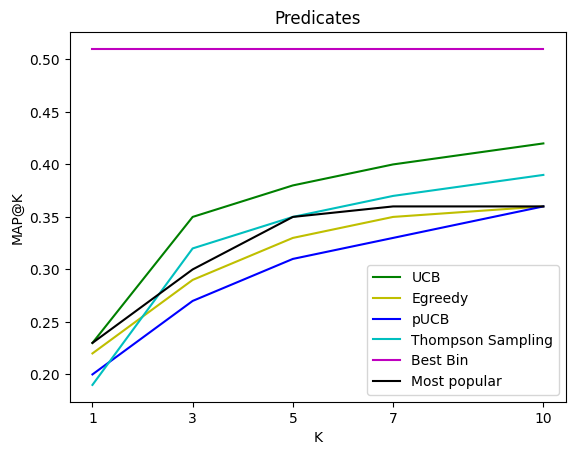

In [5]:
%%time
run_plot_parameter(tests("equal-height"), parameter_name = "K", param_map = k_to_test).results

CPU times: user 148 ms, sys: 60.7 ms, total: 208 ms
Wall time: 19.2 s


,Algorithm,1,3,5,7,10
0,UCB,0.21,0.35,0.40,0.43,0.46
1,Best Bin,0.46,0.46,0.46,0.46,0.46
2,Egreedy,0.18,0.31,0.37,0.41,0.44
3,Thompson Sampling,0.18,0.32,0.39,0.42,0.46
4,pUCB,0.22,0.37,0.42,0.44,0.46
5,Most popular,0.16,0.31,0.36,0.43,0.46


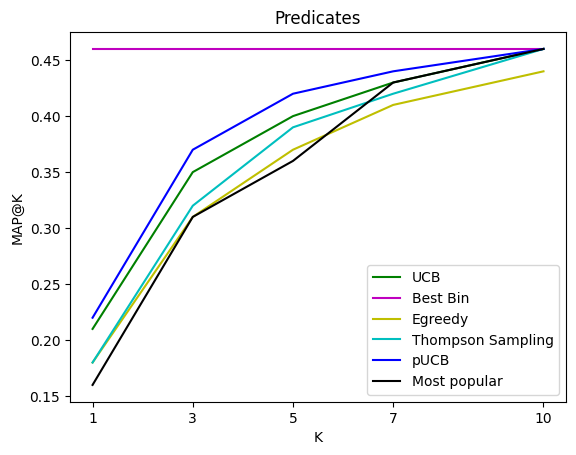

In [4]:
%%time
run_plot_parameter(tests("kmeans"), parameter_name = "K", param_map = k_to_test).results